In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\cluster\test2\CLUSTER\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'd' + str(i)
    # b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
cols_rdmc = b_name + [ "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
cols_srl = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rtd = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd = b_name+  ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


cols_sra = b_name + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rbd = b_name+  ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcc = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rd13c = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rnc = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd15n = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcn = b_name+  ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [5]:
# cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
# cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


# cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
# cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

# cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [6]:
x_RDMC = np.array(df_svc_RDMC[cols_rdmc] )
x_SRL = np.array(df_svc_SRL[cols_srl])
x_RTD = np.array(df_svc_RTD[cols_rtd])
x_RD = np.array(df_svc_RD[cols_rd])
x_SRA = np.array(df_svc_SRA[cols_sra])
x_RBD = np.array(df_svc_RBD[cols_rbd])
x_RLD = np.array(df_svc_RLD[cols_rld])
x_RD13C = np.array(df_svc_RD13C[cols_rd13c])
x_RNC = np.array(df_svc_RNC[cols_rnc])
x_RD15N = np.array(df_svc_RD15N[cols_rd15n])
x_RCN = np.array(df_svc_RCN[cols_rcn])
x_RCC = np.array(df_svc_RCC[cols_rcc])

In [7]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [8]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [9]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [10]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [11]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [12]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  15
Wavelengths to be kept  32
Optimised MSEP  46.182809359568566



[253.23474673 202.84369128 309.64425031 267.83537625 274.40507961
 316.8701496  251.71878734 216.93121439 192.47776407 259.44899711
 234.69158221 237.63665543 272.48515596 207.18792452 319.94373823
 215.73919295 250.20180974 309.47299408 255.46632847 289.27186495
 304.24899879 249.34124343 390.23844789 189.13337111 262.2037191
 333.35363649 350.63372071 304.1654996  375.81025526 260.2437387
 254.05269406 374.56696059 353.10675548 394.97413279 380.77411741
 348.42732438 323.82058266 300.87998585 307.80859507 304.73489762
 341.76403269 356.13296932 322.16481294 321.26111942 340.36674478
 327.84953883 310.65522842 290.45200045 307.12282092 320.07798955
 318.9698898  314.42361867 321.58049502 328.52310386 302.80787402
 320.69701185 327.0329247  342.5531388  313.72499451 330.32932598
 328.60140255 270.54112779 295.44483439 360.23344286 337.76869525
 328.91685186 325.00120895 334.84715815 306.19599595 309.16568039
 291.4139764  344.44558411 323.74106952 296.61849978 309.4280119
 345.01376119

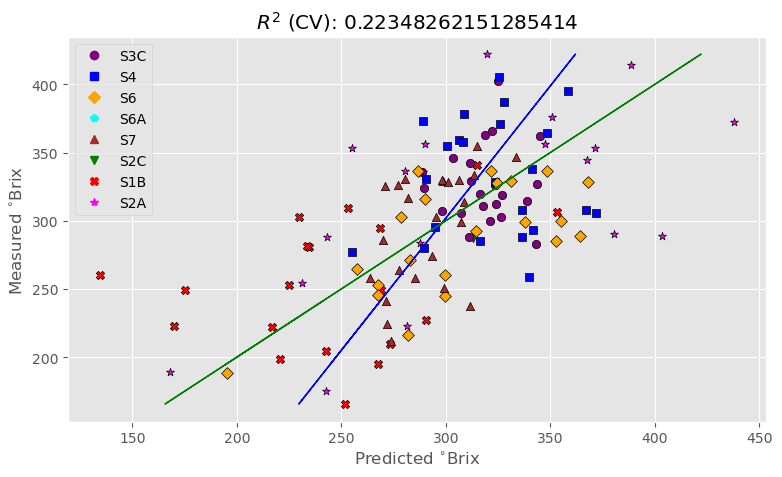

In [14]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [33]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  13
Wavelengths to be kept  43
Optimised MSEP  29.679998967899394



[101.13049871 119.22010378 130.10886286  87.77977265 115.19319352
 143.63812308 112.9636985  139.48227469  89.10722807 103.88579774
 130.80804341  70.06877246 114.54812554 155.59461604 125.46797385
 126.69037256 156.44346636  87.1680271  104.67124815  43.0169916
  98.65504008  74.12425223  53.41792521  50.75939873   9.72556211
  52.47723451  42.29126072  31.65356259  55.28394853  12.89593491
  59.68982971  36.3931105   46.0230401   59.57130501  38.20526152
  23.82241932  73.54294574 120.80929165 133.50525625  96.23644267
 121.82241603 153.04092747 120.45984018 105.17503759 129.37848219
 152.09762523 185.18209518 149.3005696  112.42862037 135.98444229
 126.33598195 145.02518503 141.32947475 135.82175965 133.91726318
 125.37605016 130.97080132  66.05269599  97.65748088 202.74514188
 155.07622922  99.70680162 120.25130603 129.12230453 128.79204327
 127.51584142 130.91678627 155.4403057  138.20680664 124.20767264
 128.24372772 140.39138607 123.51458067 131.94672786 148.61671261
 163.349028

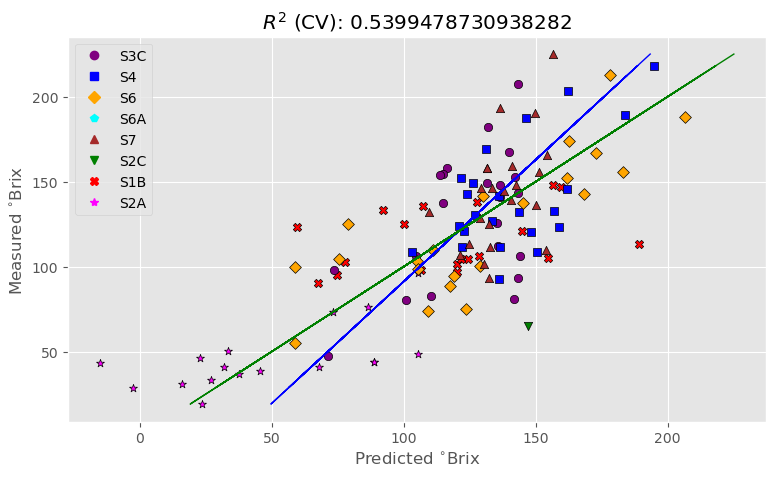

In [16]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

In [16]:
sorted_ind

array([198, 180, 212, 206, 154,  62, 178, 144, 210, 202, 152, 174, 228,
       226, 146, 194, 227, 176, 204, 200,   5, 214, 150, 142,  16, 192,
       224, 208, 140, 172, 196,  12, 182, 160,  45, 156,  60, 170, 164,
       188,  52, 158, 162, 168, 116, 190, 222,  54,   2, 184,  48,  66,
       230, 166, 186, 235, 138, 220, 217,  58,  14, 232, 148, 246, 145,
        99,  50, 211,   6, 114,  56,   4, 128,  64,  39, 126, 238, 136,
        46,  44,  88, 236,  68, 240, 203, 234,  90, 112, 104, 110,   8,
       216, 106, 218, 175,  86, 134, 124, 141,  92,  18, 163,  22, 108,
       179, 125,  84, 153,  94, 130,  75,  96,  20,  24,  10,  76,  98,
       100,  32,  74,  95,  82,   3, 102,  34, 213,  70, 118,  80, 132,
        78,  42,  26,  72,  36,  30, 177,  40, 121,  38,   0,  28,  21,
       169, 157, 120,  79, 122, 111,  89, 143, 221,  19, 195, 205, 243,
        57,  29,  71,  51,  85, 193, 199, 159, 133, 209,  97, 189, 119,
         7, 105, 135, 225, 131, 107, 185,   9, 231, 237, 197, 12

In [41]:
optimal_pls = PLSRegression(n_components = 13)
optimal_pls.fit(opt_Xc, y_SRL.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(cols_srl)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(43,) (43,)


array([ 18.33330036,  15.13791979,   8.46167696,  -2.64690847,
        14.66524473, -11.42776874, -17.47870856,   8.60347264,
        13.41634978, -10.58231367,   9.95864673,  10.23540009,
        -3.0634247 ,  14.32253839,  -3.15062394,   2.96992266,
         2.2278167 , -19.69312903,  -9.57615748, -20.94719724,
        13.93916195,  19.88160816,   1.26948231,  -7.93966447,
         4.63381007,  -5.85984001, -15.0414025 ,  -5.53938564,
       -18.53874892,  10.16458728,  -7.87416597,  15.24719633,
        12.20013923, -29.07572359, -10.81218818,  -0.49490199,
       -16.03870794,  20.79155442, -25.51458522,  12.99986561,
        17.81258042,  -6.98949352,  19.705342  ])

In [38]:
optimal_pls.intercept_


array([119.05814089])

In [39]:
bands

array(['d41', 'd44', 'd100', 'd31', 'd37', 'd25', 'd16', 'd53', 'd59',
       'd92', 'M_relative_abund_sum', 'd96', 'd112', 'd33', 'd83', 'd101',
       'd24', 'd78', 'd39', 'd35', 'd18', 'd58', 'd115', 'd30', 'd13',
       'd91', 'd47', 'd74', 'd34', 'd86', 'd117', 'G_relative_abund_sum',
       'd19', 'd110', 'd22', 'd57', 'd46', 'd75', 'd32', 'd52', 'd108',
       'F_relative_abund_sum', 'd6'], dtype='<U21')

In [40]:
coefficients

array([18.33330036])

## RTD
 

In [17]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 25)


Optimised number of PLS components:  11
Wavelengths to be kept  48
Optimised MSEP  0.07292649632687914



[0.33942586 0.31074833 0.22303543 0.35984333 0.45874211 0.43037121
 0.42210591 0.3232525  0.41762551 0.39288485 0.46429278 0.41034251
 0.5905458  0.46127306 0.56678509 0.46599329 0.45427237 0.50935475
 0.49417315 0.33513442 0.25164446 0.31576801 0.63577705 0.55766508
 0.559809   0.48683999 0.61468186 0.44967181 0.52047833 0.50721628
 0.39039063 0.63297246 0.51089438 0.45865675 0.56807022 0.26073263
 0.46913795 0.56263026 0.49345386 0.44625735 0.49640866 0.43631518
 0.5139834  0.45073058 0.46190973 0.44991565 0.43962915 0.44624079
 0.50242792 0.47479587 0.48220405 0.42658546 0.44090906 0.47577414
 0.46768167 0.47933919 0.42048098 0.50003087 0.54510785 0.54480234
 0.57686188 0.55763256 0.54644452 0.53329486 0.50840906 0.46436383
 0.54647034 0.56539642 0.55750178 0.5660289  0.38791537 0.50842948
 0.55802862 0.55097882 0.48447384 0.49794679 0.55294086 0.5493968
 0.548643   0.619283   0.48383314 0.42622307 0.48689319 0.43996931
 0.45283462 0.42255037 0.43814308 0.43272061 0.44470668 0.42716

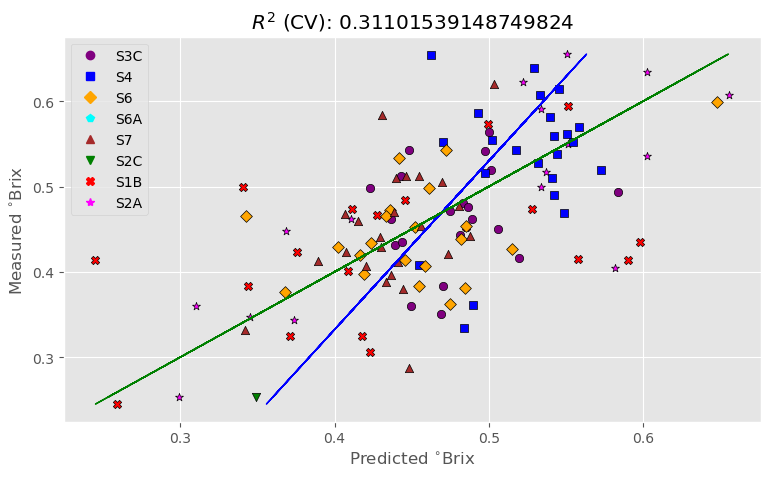

In [18]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [42]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 25)


Optimised number of PLS components:  16
Wavelengths to be kept  25
Optimised MSEP  0.02673864191574982



[0.12409624 0.12034754 0.1401809  0.13228384 0.12697472 0.13801584
 0.1273551  0.13903708 0.13533937 0.128849   0.12023558 0.14247742
 0.12345451 0.13371323 0.14165207 0.1414139  0.15542003 0.13094484
 0.13267914 0.13412914 0.1354526  0.13036905 0.13554895 0.14349441
 0.14547704 0.12406207 0.12723811 0.14236505 0.14279528 0.1316265
 0.13304824 0.15471894 0.13235929 0.14920189 0.16249131 0.13207358
 0.15759438 0.13891181 0.14178298 0.14319905 0.1581116  0.13837781
 0.15191872 0.13117578 0.13705169 0.14141932 0.12881629 0.14149332
 0.13981728 0.15421894 0.15780427 0.13420199 0.1585566  0.12765297
 0.14376783 0.14243022 0.13073371 0.16501322 0.14639427 0.15427481
 0.1472614  0.14306188 0.16966187 0.17688526 0.14960475 0.14820694
 0.15642001 0.17275885 0.16334125 0.15192165 0.15472353 0.15645375
 0.14305186 0.16577199 0.14266604 0.1819541  0.14847631 0.17529454
 0.16880319 0.17143062 0.18296293 0.15275887 0.1731961  0.13016255
 0.15180553 0.16307481 0.13539658 0.15030412 0.13930625 0.15593

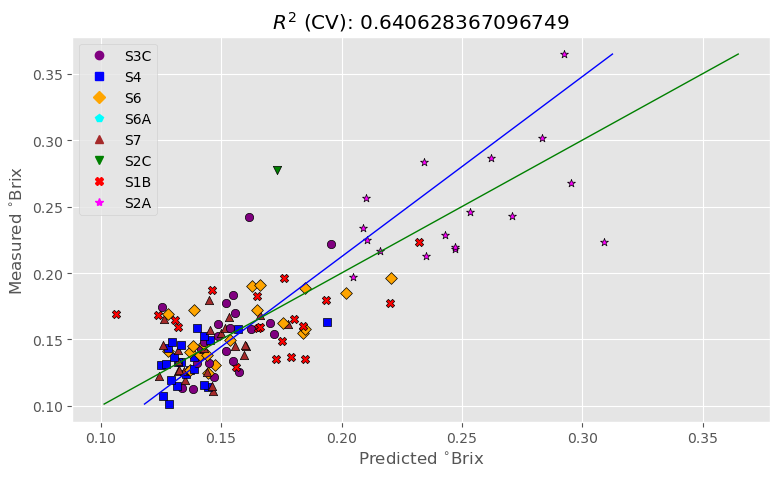

In [43]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

In [44]:
optimal_pls = PLSRegression(n_components = 16)
optimal_pls.fit(opt_Xc, y_RD.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(cols_rd)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients


(25,) (25,)


array([ 0.0034344 , -0.00738902,  0.0136807 ,  0.00886236, -0.0335986 ,
        0.0043546 ,  0.01245776,  0.00322395, -0.01563085,  0.01063521,
        0.01332692, -0.0077559 , -0.01500148,  0.00154089,  0.00912132,
       -0.00018248,  0.01457909,  0.0128884 , -0.0211283 ,  0.02558462,
        0.01281078, -0.01831331,  0.00956732, -0.01441956,  0.00929774])

In [45]:
optimal_pls.intercept_

array([0.16445648])

In [46]:
bands

array(['d17', 'd72', 'd46', 'd35', 'd59', 'd117', 'd32', 'd96', 'd14',
       'd102', 'd20', 'd6', 'd13', 'd95', 'd81', 'd75', 'd47', 'd110',
       'd44', 'd24', 'F_relative_abund_sum', 'd56', 'd74', 'd86', 'd8'],
      dtype='<U21')

# SRA

In [13]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  17
Wavelengths to be kept  46
Optimised MSEP  93.11365564265945



[585.34902831 717.51949015 750.5407443  564.11790983 487.92498252
 600.15384013 524.94639769 717.71534567 552.373191   588.99722254
 655.99460488 494.13877805 418.26839683 617.37278039 533.99892957
 567.49086389 670.99486515 520.98804626 520.84619758 412.68793101
 650.94047545 528.39804962 302.82513689 336.64241443 222.07311811
 382.2192592  320.73543464 311.31587533 398.58064158 189.7211234
 380.20444118 288.97871651 332.72988765 380.67194627 291.27390246
 191.59877257 520.13305487 547.3096314  516.42705265 447.74790763
 527.58146602 610.1694276  542.10976387 501.72184541 561.41370792
 654.6458784  730.91669037 650.86330184 529.99911933 622.65281455
 561.24112934 639.86671727 528.64428309 561.04695611 567.22876282
 533.93191914 483.52820292 504.39449611 806.64294896 637.75082486
 489.59425206 538.35836856 540.22816005 541.07653026 541.82701692
 539.83350337 603.32891934 636.36011969 510.64944114 565.87792595
 553.13696595 538.47205338 644.0684479  608.88202335 623.55839117
 551.970582

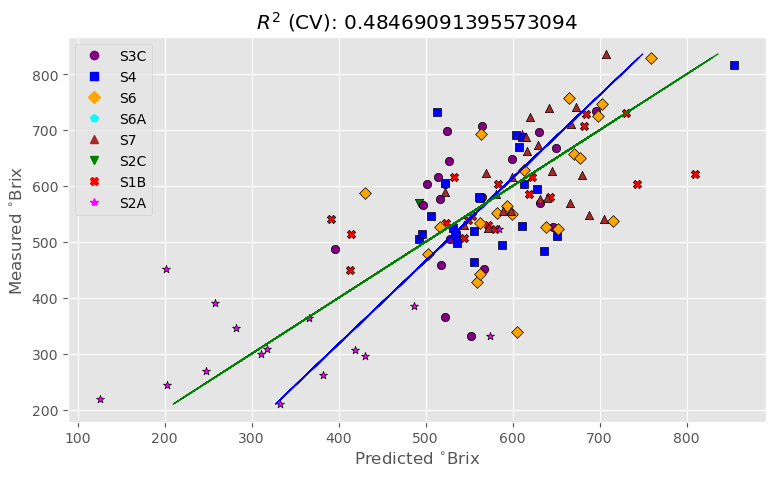

In [15]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [16]:
optimal_pls = PLSRegression(n_components = 17)
optimal_pls.fit(opt_Xc, y_SRA.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(cols_sra)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients


(46,) (46,)


array([-28.33677044,  14.9841428 ,  39.05242864,  10.93103811,
        -7.55854321,   8.59314491,  26.80935598,  19.05357301,
       -14.99280106,  37.84418612, -11.48677606, -12.31517166,
        41.74143677,  -8.45586796,   6.3018359 ,  12.06967968,
        11.77327899,  10.6486303 , -18.34853025, -55.1526429 ,
        31.47901632,  49.4589139 , -43.43842145,  45.52903614,
        30.07457028,  16.7742977 ,  38.70811979, -23.78154973,
       -47.67027481,  11.58098336, -20.82336703,  42.47031469,
        44.11516315, -59.11566652, -52.68189978, -34.58236979,
         1.82920284, -88.6111718 ,  34.61281766,  72.61304465,
       -72.18462701,  70.56173522, -61.0313768 ,  66.92531262,
       -57.99379916,  58.60693083])

In [17]:
optimal_pls.intercept_

array([555.51318751])

In [18]:
bands

array(['d113', 'd73', 'd87', 'd10', 'd68', 'd14', 'd8', 'd106', 'd53',
       'd69', 'd117', 'd30', 'd118', 'F_relative_abund_sum', 'd35', 'd89',
       'd33', 'd18', 'd22', 'd25', 'd37', 'd100', 'd83', 'd20', 'd58',
       'd19', 'G_relative_abund_sum', 'd112', 'd110', 'd34', 'd115',
       'd86', 'd96', 'd91', 'd74', 'd16', 'd97', 'd32', 'd57', 'd75',
       'd78', 'd108', 'd46', 'd6', 'd39', 'd52'], dtype='<U21')

## RBD

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 20)



Optimised number of PLS components:  14
Wavelengths to be kept  52
Optimised MSEP  0.0033418563336535265



[ 0.00200853  0.00182352  0.00466304  0.00110496 -0.00012065  0.00220513
  0.00092141  0.00197477  0.00345659  0.0055819   0.00343035  0.00112009
  0.00507873  0.01495278  0.00475602  0.00146776  0.00061807  0.00874888
  0.00671706  0.00377567  0.00040437  0.00253567 -0.00040181  0.00581223
  0.00657561  0.00837531  0.00482142  0.01698237  0.01252895  0.00850671
  0.00979658  0.00642553  0.01184639  0.00376474  0.00226193  0.01225991
  0.01407571  0.00991645  0.01835216  0.00231236  0.00211624  0.00696806
  0.00756982  0.00776433  0.00455047  0.00441423  0.0045481   0.0090013
  0.00330413  0.0036683   0.00840298  0.00639784  0.00245269  0.0050307
  0.00430289  0.00668635  0.0073723   0.00661903  0.00743619  0.00507605
  0.00515529  0.00064548  0.00385914  0.00678204  0.00786043  0.0077564
  0.00840843  0.01375119  0.00985281  0.00795008  0.00681345  0.00850342
  0.00269682  0.0090429   0.00655516  0.01125319  0.00769774  0.00759615
  0.00637415  0.01269601  0.01152859  0.00963722  0.00

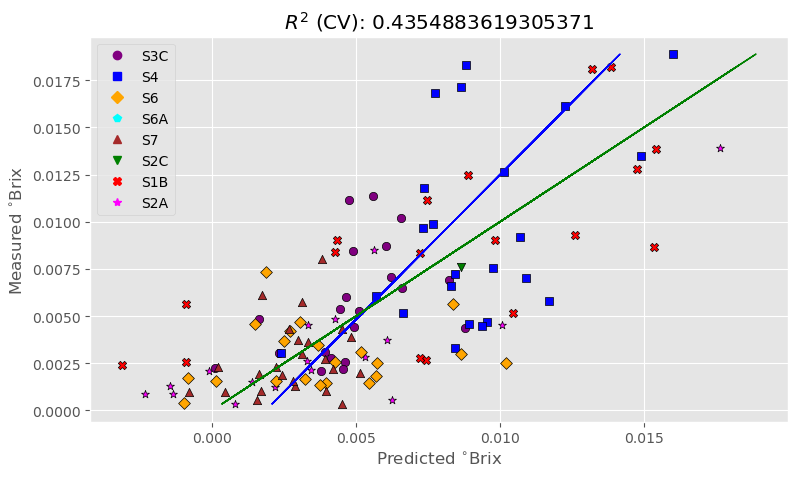

In [20]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [21]:
optimal_pls = PLSRegression(n_components = 14)
optimal_pls.fit(opt_Xc, y_RBD.astype(np.float64))

coefficients = np.ravel(optimal_pls.coef_) 
bands = np.array(cols_rbd)[sorted_ind][wav:]

print(coefficients.shape, bands.shape)

coefficients

(52,) (52,)


array([ 1.34848019e-03, -1.38109964e-03,  2.29227662e-03,  1.91560066e-04,
        1.19415731e-03,  5.41468712e-04,  3.99914562e-04, -2.73061055e-04,
        1.08762535e-03, -9.09175446e-05,  1.20181227e-03, -7.59276447e-04,
        7.73449394e-04,  6.94724051e-05,  6.80494543e-05,  3.15098593e-04,
        1.44200328e-03,  1.79321089e-04,  3.36773205e-04,  2.47976544e-04,
       -5.48878666e-05, -5.19847962e-04,  8.94435817e-04, -3.64472203e-04,
        1.01098884e-03, -1.43307671e-03,  7.73818922e-04, -1.07381929e-03,
        1.14981281e-03,  6.47109347e-04,  1.27535014e-03,  7.24049001e-04,
        2.05208410e-04, -6.61888940e-04, -2.17345024e-03,  1.22285949e-03,
       -2.09095766e-03, -1.02014445e-03, -1.86573155e-03, -1.18400502e-03,
        1.26666770e-03, -1.95644679e-03, -1.52293323e-03, -1.01928707e-03,
       -1.24420432e-03, -9.21418366e-04,  1.65952156e-03,  7.76047402e-04,
       -4.65043151e-04,  1.49684223e-03, -1.65666812e-03, -1.30718668e-03])

In [22]:
optimal_pls.intercept_

array([0.00550475])

In [23]:
bands

array(['d113', 'd33', 'd61', 'd9', 'b1', 'b2', 'd10', 'd45', 'd49', 'd68',
       'd25', 'd93', 'd100', 'd91', 'd104', 'd120', 'd79', 'd90', 'd56',
       'd72', 'd32', 'd5', 'd47', 'd69', 'd96', 'd92', 'd82', 'd7', 'd11',
       'M_relative_abund_sum', 'd106', 'd114', 'd87', 'd29', 'd81', 'd71',
       'd88', 'd18', 'd94', 'd30', 'd84', 'd50', 'd28', 'd2', 'd34',
       'd118', 'd44', 'd12', 'd102', 'd78', 'F_relative_abund_sum', 'd6'],
      dtype='<U21')

## RLD

In [25]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  12
Wavelengths to be kept  50
Optimised MSEP  2.894851055736915



[-0.79620302  1.05021251  1.48927537  0.99451137  0.78780957  1.95147836
  1.80344895  1.87228384  5.78971476  1.28280957  1.45851068  1.79744134
  3.74777771  1.62943953  2.51783941  0.95287748  2.08852628  3.1878204
  3.83007395  1.79291876  1.93216299  2.94573366  3.21029025  2.98347029
  3.75630736  0.99512335  5.19624171  3.50357498  7.2473714   4.06912177
  2.6366011   2.36160828  3.31398728  5.069687    6.13718125  5.85729293
  6.40971924  3.640564    4.97965387  4.50491813  4.8462815   4.93856927
  6.34951669  4.46186684  6.51157635  5.22692239  5.21685215  5.76388271
  5.42081621  6.0659681   4.74774559  5.87813633  8.8391663   6.99497375
  5.41032711  4.16739801  4.70274232  5.69558643  6.18717732  5.91651715
  3.56793794  5.20293376  4.66306734  7.39408106  6.25123009  5.55007327
  4.53153206  6.31678224  6.470563    2.32496014  6.75373018  6.9764368
  6.00257737  7.92210256  7.79413041  4.42807464  9.57631249  6.59225819
  6.28557509  6.94619215  5.86896794  9.34425213  8.8

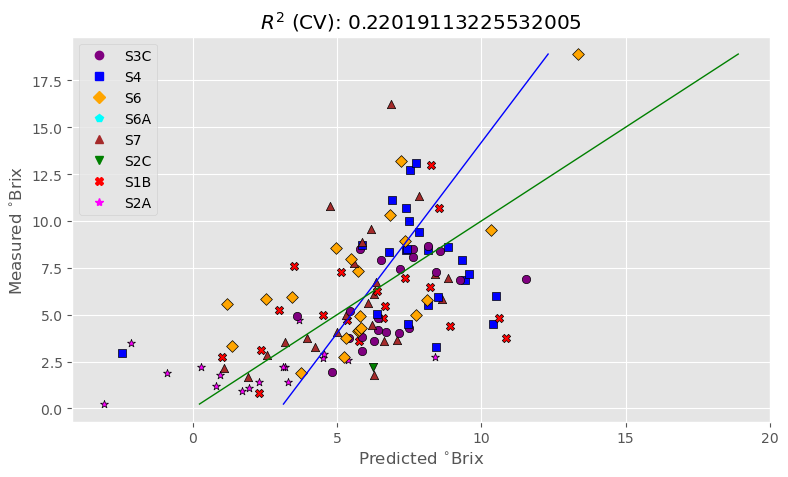

In [26]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [27]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  10
Wavelengths to be kept  68
Optimised MSEP  0.7541269462718142



[-28.15484729 -28.72248955 -27.83720275 -28.75151977 -28.89068398
 -29.23092047 -27.7588434  -28.61039268 -29.06764533 -26.84569953
 -27.70226098 -29.20992797 -28.61651255 -27.1024428  -28.19377807
 -27.87104821 -27.75002287 -28.16334361 -28.085608   -26.95295506
 -29.93752419 -26.1149518  -26.88260907 -27.06828314 -26.28636177
 -28.947859   -28.12382259 -28.01041694 -28.47803157 -28.29015256
 -29.0205502  -27.89206018 -27.66296633 -26.28086302 -28.45561481
 -26.79816669 -27.87179694 -27.37758516 -29.57523568 -28.20746981
 -28.21096344 -26.4370591  -27.89339606 -26.20516574 -28.59596966
 -27.12855803 -28.11390512 -27.27105432 -27.35138261 -27.45278314
 -28.11582496 -27.64312478 -28.15599749 -28.32546204 -27.8572774
 -28.07653298 -27.69189485 -27.50843162 -27.99015312 -27.54340616
 -27.70208608 -27.85307677 -27.72073772 -27.78217462 -28.73791934
 -28.54823646 -27.95993081 -28.19996985 -28.08197663 -28.49562146
 -28.95764094 -28.54354336 -28.07659537 -27.39657553 -28.38848988
 -28.176217

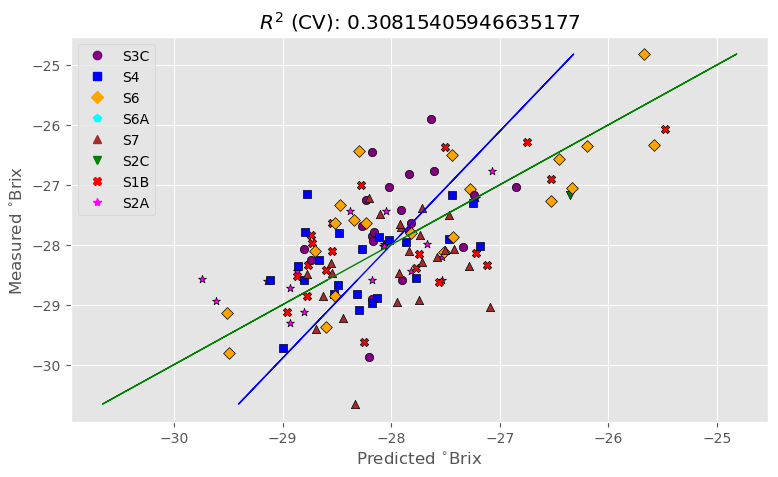

In [28]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  9
Wavelengths to be kept  47
Optimised MSEP  1.5768990015295177

[13.2194142  12.25564957 11.20533611 12.79049829  8.70205764 12.6724827
 10.06406543  7.45216054  9.0207894   6.94137553  7.17420111  6.77121204
  9.35673574  6.11915151  9.33487298  7.02819533  8.68820063  8.97781162
  7.7520142  10.79042602  6.14997577  9.54626084  9.81624881  7.67116746
 10.73798411 10.57239872  9.54585948 11.18855902 10.07743952 13.85383445
 14.03528275 10.19652454  7.92418075 12.74691103 12.29514707 11.26662593
  7.72041705 11.40689341 13.79058457 13.68763733  8.79577857  8.3213063
  9.98113567  8.59460435  9.03541668  7.94926009  9.96495015 11.25808355
 11.55448276  9.45507943  8.51948773  9.88731367 11.32400657  9.85364055
  9.09511209  9.86280703 10.14867323 10.43767033  9.56457802 10.02116977
  9.62767302 10.40399818  9.85986952  9.9735386  10.39470241  9.47889028
 12.54826821 11.57903454 11.07884483  9.95371219  9.8872803  10.38023434
 11.25418146  9.9259499

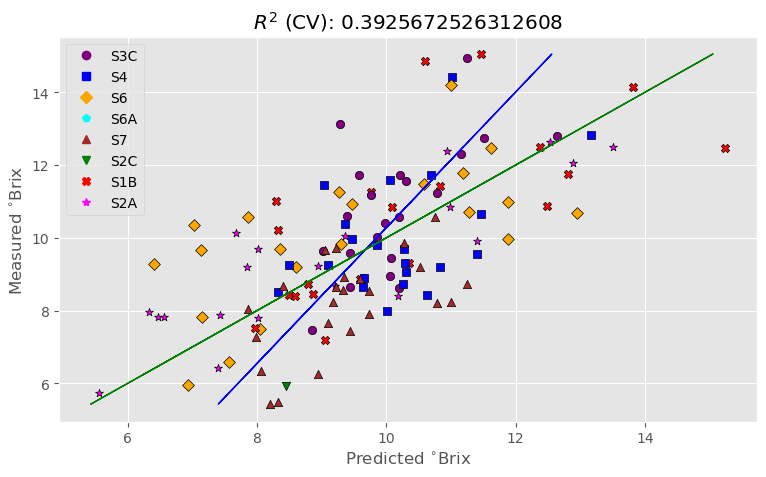

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  11
Wavelengths to be kept  54
Optimised MSEP  1.371971148483794

[ 2.76023722  0.38418607  1.10551057  2.06333181  1.52232833  1.91332965
 -0.60079768 -1.56272482 -0.20039948 -1.13839277 -1.72501276 -0.17840409
  0.5147594  -5.15862833 -0.13871366 -4.39233228 -0.98457024  0.32674608
 -2.83817185 -0.26257608  2.13448313 -3.42720277  2.58657324  3.59057785
  3.05851942  2.46938203  1.67141355  1.41022808  1.6489018  -0.42052885
  0.4495826   2.3376488   1.98603153  2.99964985  1.79527628  4.11338582
  1.93302563 -1.1922119  -1.24910163  1.00723491 -0.48963535  1.77122606
  1.18849673 -1.17259949  1.49159536  1.2935448  -0.56469974 -0.34404141
  1.13157665  0.40963206  0.55589079 -0.0119465   0.3108542   0.63472633
 -1.08477657 -0.63702987  0.45468353  0.68634505  0.37925569  0.2226319
  0.14569112 -0.38164485  0.28474473  0.50872375 -0.29969541  1.53339877
 -0.82408677  0.26096462  0.05859644  0.27626229 -0.81483952 -1.31838942
 -1.51483653 -0.483560

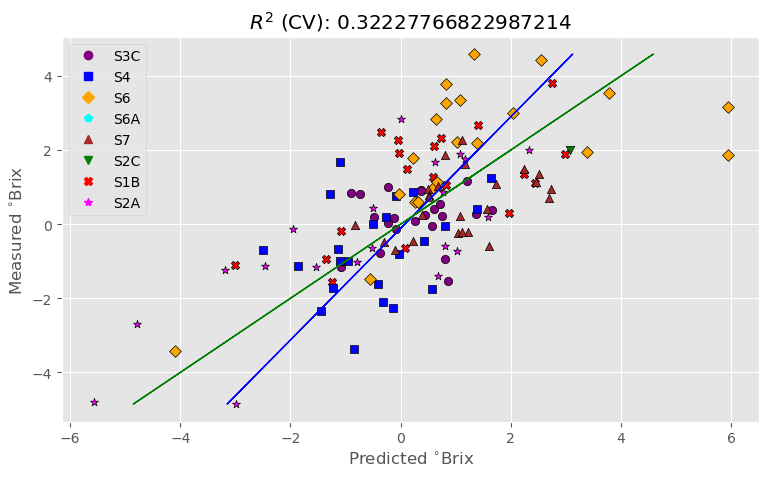

In [30]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  6
Wavelengths to be kept  20
Optimised MSEP  8.333972745954613

[34.38530757 33.87894472 43.23702371 36.33682045 51.15842159 34.98798635
 53.59583683 55.28955202 51.68731534 69.33192047 66.53405927 62.64743761
 53.94677927 82.68019373 51.58407674 66.2583873  58.77729284 60.61736289
 65.95036672 62.38989965 69.08455582 51.51718168 53.10659057 58.58390736
 50.56185161 41.69960616 46.61746711 35.93245561 40.04442332 37.10956202
 36.08985891 41.71801508 47.18206903 30.56811082 40.68637859 44.43986371
 62.1681736  41.85784648 38.36252138 39.81326413 56.39869615 50.17696894
 49.45910175 50.04786534 60.9207564  49.68002402 47.03358706 42.98818861
 40.49713786 46.4598996  44.57108133 46.657246   40.72648677 48.71320971
 46.83768207 41.8721628  44.35444384 41.58462854 46.93493946 45.68850854
 46.20428813 47.15856311 46.98717175 42.67762603 42.57097207 46.10904158
 33.03585412 36.92947331 36.78267416 45.93962397 49.31877894 45.4641323
 42.33378918 49.7521376

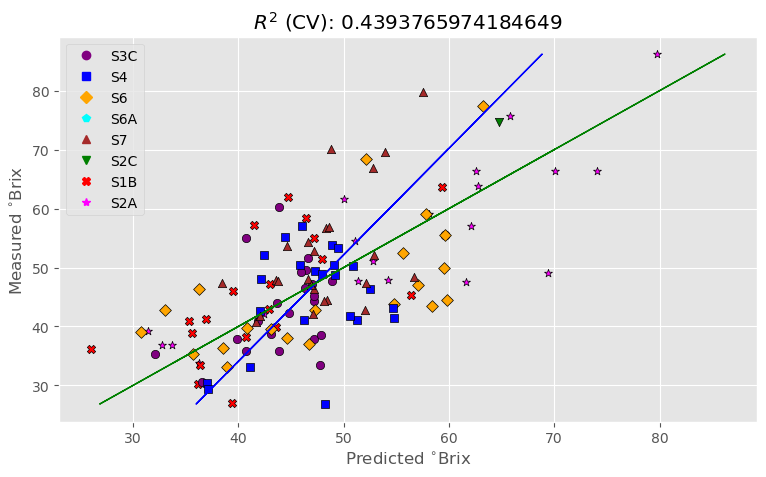

In [31]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  10
Wavelengths to be kept  40
Optimised MSEP  27.101651759135677

[433.26385035 452.10302571 461.57925609 478.71629157 437.89426711
 464.72812055 472.24485452 492.6066856  481.35654426 488.2575752
 533.70835925 494.90111163 511.42543636 499.43824942 466.56080952
 507.28237367 494.57974004 509.24648497 515.72999216 479.49622738
 443.80916841 489.61812999 428.88201184 450.1804364  478.67306752
 448.00936552 493.33517966 416.26651034 425.52765522 414.27199763
 423.8132991  440.40057296 409.4680842  452.4330583  477.83942748
 487.63577753 467.51731125 480.61418695 482.46011587 504.0570101
 464.14377888 484.34892426 484.45463186 463.94613652 496.47194354
 458.79946448 391.68646557 434.76280678 479.11007531 429.19996594
 444.93971852 449.00605658 451.40117774 451.36602352 439.74067269
 481.13109897 451.22279353 443.1502491  427.96374009 456.13910922
 438.78371334 441.39260922 444.99465925 457.4129139  444.6480877
 451.92610978 437.73421371 449.9028801  4

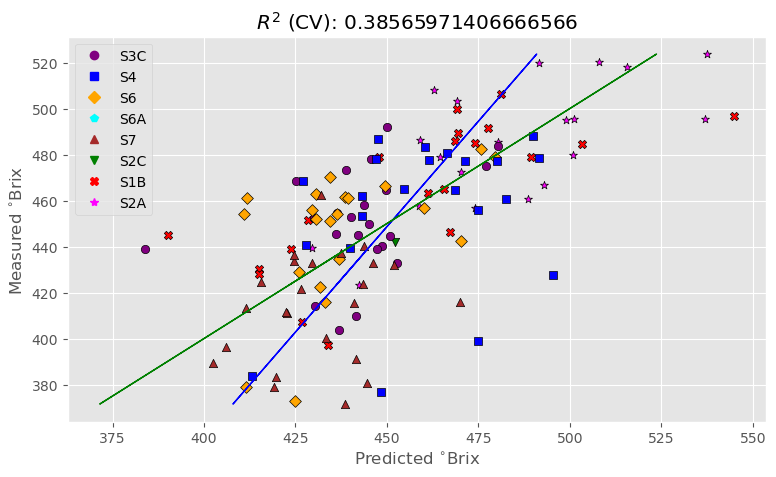

In [32]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
